# 📈 Green Bond Thesis — Event Study & Parallel Trends Test
**Title:** Do Politicians' Words Have a Dollar Value?  
**Author:** Nahian Ibnat  
**Supervisor:** Zoltán Csaba Tóth  
**Institution:** Central European University — MA in Economics, Data & Policy  
**Date:** April 2026

---

## What This Notebook Does

This notebook implements the **Event Study** and **Parallel Trends Test** for the thesis.  
These are required to validate the causal identification strategy in the DiD framework.

### Why This Matters

The staggered Difference-in-Differences (DiD) estimator in the main regression notebook (M5) uses a single **Post** dummy to capture the treatment effect. This imposes a strong assumption: that the treatment effect is **constant** across all post-event days.

The event study relaxes this assumption by estimating a **separate coefficient for each week** around the treatment date:

$$\Delta y_{i,t} = \sum_{k=k_{min}}^{k_{max}} \beta_k D^{(k)}_{c,t} + \alpha_i + \delta_t + \varepsilon_{i,t}$$

where $D^{(k)}_{c,t}$ is a dummy equal to 1 when observation $(i,t)$ is $k$ weeks relative to the treatment event in country $c$.

### Two Things This Tests

| Test | What to Look For | Purpose |
|------|-----------------|---------|
| **Parallel Trends** | Pre-event coefficients ($k < 0$) close to zero and insignificant | Validates DiD identification — confirms no pre-existing trend before treatment |
| **Treatment Effect** | Post-event coefficients ($k > 0$) significant and negative | Tests H3 — did the policy event widen the Greenium? |

### Treatment Events

| Country | Event | Date |
|---------|-------|------|
| India | Inaugural Sovereign Green Bond Auction | 25-Jan-2023 |
| Indonesia | JETP Announcement at G20 Bali | 15-Nov-2022 |

> **Run all cells sequentially top to bottom.**  
> This notebook requires the same data files as `GreenBond_Regression_v3.ipynb`.


---
# Part 1 — Setup


## 1.1 — Install Dependencies

In [1]:
!pip install -q openpyxl pandas numpy statsmodels matplotlib scipy

## 1.2 — Imports

In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported.")


✓ Libraries imported.


## 1.3 — File Paths

Same paths as the main regression notebook. Only change ROOT if your folder differs.


In [3]:
# ── Root directory ─────────────────────────────────────────────────────────────
ROOT = '..'  # Notebook lives in Thesis/notebooks/, so '..' points to Thesis/

# ── Bond yield files ───────────────────────────────────────────────────────────
BOND_FILES = {
    # ── Original India pairs ──────────────────────────────────────────────────
    'IND_CONV_5Y':         os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_CONV_5Y_IN072629G_01Jan2020_21Apr2026.xlsx'),
    'IND_CONV_10Y':        os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_CONV_10Y_IN0020190362_01Jan2020_21Apr2026.xlsx'),
    'IND_GREEN_5Y':        os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_GREEN_5Y_IN0020230143_13Nov2023_20Apr2026.xlsx'),
    'IND_GREEN_10Y':       os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'IND_GREEN_10Y_IN0020220144_27Jan2023_20Apr2026.xlsx'),
    # ── New India pairs ───────────────────────────────────────────────────────
    # India NEW 5Y:  Green 7% 2028 (IN071028G) + Conventional 7% 2029 (IN071029G)
    'IND_GREEN_5Y_NEW':    os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'India_Green_7pct_2028_IN071028G.xlsx'),
    'IND_CONV_5Y_NEW':     os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'India_Conventional_7pct_2029_IN071029G.xlsx'),
    # India NEW 10Y: Green 7.29% 2033 (IN072933G) + Conventional 7.26% 2032 (IN072632G)
    'IND_GREEN_10Y_NEW':   os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'India_Green_7pct29_2033_IN072933G.xlsx'),
    'IND_CONV_10Y_NEW':    os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'india_bond',     'India_Conventional_7pct26_2032_IN072632G.xlsx'),
    # ── Indonesia pairs (unchanged) ───────────────────────────────────────────
    'IDO_CONV_10Y':        os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_CONV_10Y_US455780DN36_20Sep2022_20Apr2026.xlsx'),
    'IDO_CONV_2033':       os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_CONV_2033_US455780DR40_11Jan2023_20Apr2026.xlsx'),
    'IDO_GREEN_10Y':       os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_GREEN_10Y_US71567RAV87_06Jun2022_20Apr2026.xlsx'),
    'IDO_GREEN_2033':      os.path.join(ROOT, 'data', 'raw', 'bond_yield_data', 'indonesia_bond', 'IDO_GREEN_2033_US71567RAY27_15Nov2023_20Apr2026.xlsx'),
}

# ── Control variable files ─────────────────────────────────────────────────────
VIX_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'vix',           'VIXCLS.csv')
INR_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDINR_INR_01Jan2020_20Apr2026.xlsx')
IDR_FILE       = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'exchange_rate', 'CTRL_USDIDR_IDR_01Jan2020_20Apr2026.xlsx')
CDS_INDIA_FILE = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds',           'CTRL_CDS5Y_India_INGV5YUSAC_01Jan2020_26Sep2025.csv')
CDS_INDO_FILE  = os.path.join(ROOT, 'data', 'raw', 'control_variables', 'cds',           'CTRL_CDS5Y_Indonesia_IDGV5YUSAC_01Jan2020_17Apr2026.csv')
SENTIMENT_FILE = os.path.join(ROOT, 'data', 'processed', 'gdelt', 'daily_sentiment_gdelt.csv')

# ── Output directory ───────────────────────────────────────────────────────────
OUTPUT_DIR    = os.path.join(ROOT, 'notebooks')
OUTPUT_FOLDER = os.path.join(ROOT, 'output', 'regression')
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── Twin-bond pairs ────────────────────────────────────────────────────────────
PAIRS = [
    # ── Original India pairs ──────────────────────────────────────────────────
    ('IND_GREEN_10Y',     'IND_CONV_10Y',     'India', '10Y_orig'),
    ('IND_GREEN_5Y',      'IND_CONV_5Y',      'India', '5Y_orig'),
    # ── New India pairs ───────────────────────────────────────────────────────
    ('IND_GREEN_5Y_NEW',  'IND_CONV_5Y_NEW',  'India', '5Y_new'),   # Green 2028 / Conv 2029
    ('IND_GREEN_10Y_NEW', 'IND_CONV_10Y_NEW', 'India', '10Y_new'),  # Green 2033 / Conv 2032
    # ── Indonesia pairs (unchanged) ───────────────────────────────────────────
    ('IDO_GREEN_10Y',     'IDO_CONV_10Y',     'Indonesia', '10Y'),
    ('IDO_GREEN_2033',    'IDO_CONV_2033',    'Indonesia', '2033'),
]

# ── Treatment dates ────────────────────────────────────────────────────────────
TREATMENT_DATES = {
    'India':     pd.Timestamp('2023-01-25'),
    'Indonesia': pd.Timestamp('2022-11-15'),
}

# ── Chart colours ──────────────────────────────────────────────────────────────
TEAL     = '#1D9E75'
ORANGE   = '#E85D24'
BLUE     = '#4C9BE8'
GRAY     = '#8892a4'
WHITE    = '#e8eaf0'
BG       = '#0f1117'
PANEL_BG = '#1a1d27'

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=GRAY, labelsize=8)
    ax.xaxis.label.set_color(GRAY)
    ax.yaxis.label.set_color(GRAY)
    ax.title.set_color(WHITE)
    for s in ax.spines.values():
        s.set_edgecolor('#2a2d3a')

# ── Path check ─────────────────────────────────────────────────────────────────
print("Path verification:")
for name, path in [
    ('VIX',              VIX_FILE),
    ('Sentiment',        SENTIMENT_FILE),
    ('IND_CONV_5Y',      BOND_FILES['IND_CONV_5Y']),
    ('IND_GREEN_5Y_NEW', BOND_FILES['IND_GREEN_5Y_NEW']),
    ('IND_CONV_5Y_NEW',  BOND_FILES['IND_CONV_5Y_NEW']),
    ('IND_GREEN_10Y_NEW',BOND_FILES['IND_GREEN_10Y_NEW']),
    ('IND_CONV_10Y_NEW', BOND_FILES['IND_CONV_10Y_NEW']),
    ('IDO_GREEN_10Y',    BOND_FILES['IDO_GREEN_10Y']),
]:
    status = "\u2713 OK" if os.path.exists(path) else "\u2717 NOT FOUND"
    print(f"  {name:<22} {status}")


Path verification:
  VIX                    ✓ OK
  Sentiment              ✓ OK
  IND_CONV_5Y            ✓ OK
  IND_GREEN_5Y_NEW       ✓ OK
  IND_CONV_5Y_NEW        ✓ OK
  IND_GREEN_10Y_NEW      ✓ OK
  IND_CONV_10Y_NEW       ✓ OK
  IDO_GREEN_10Y          ✓ OK


## 1.4 — Helper Functions

In [4]:
import openpyxl

def load_bond_ytm(filepath):
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows) if r[0] and 'date' in str(r[0]).lower())
    df = pd.DataFrame(
        [r for r in rows[hdr_idx+1:] if r[0] is not None],
        columns=rows[hdr_idx]
    )
    df['date'] = pd.to_datetime(df['Date'])
    df['ytm']  = (df['BidYld'] + df['AskYld']) / 2
    return df[['date', 'ytm']].dropna().sort_values('date').reset_index(drop=True)

def load_fx(filepath, col_name):
    wb = openpyxl.load_workbook(filepath)
    ws = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdr_idx = next(i for i, r in enumerate(rows)
                   if r[0] and 'exchange date' in str(r[0]).lower())
    df = pd.DataFrame(
        [r for r in rows[hdr_idx+1:] if r[0] is not None],
        columns=rows[hdr_idx]
    )
    df['date']   = pd.to_datetime(df['Exchange Date'])
    df[col_name] = (df['Bid'] + df['Ask']) / 2
    return df[['date', col_name]].dropna().sort_values('date')

def load_cds(filepath, col_name):
    df = pd.read_csv(filepath)
    df.columns = ['date', col_name, 'open', 'high', 'low', 'chg']
    df['date']  = pd.to_datetime(df['date'])
    return df[['date', col_name]].dropna()

print("✓ Helper functions defined.")


✓ Helper functions defined.


---
# Part 2 — Data Loading & Panel Construction

Identical pipeline to the main regression notebook. Run these cells to reproduce the clean panel.


## 2.1 — Load Bond Yields & Compute Greenium

In [5]:
bond_dfs = {}
for key, fpath in BOND_FILES.items():
    bond_dfs[key] = load_bond_ytm(fpath)

panels = []
for gkey, ckey, country, tenor in PAIRS:
    g = bond_dfs[gkey].rename(columns={'ytm': 'ytm_green'})
    c = bond_dfs[ckey].rename(columns={'ytm': 'ytm_conv'})
    m = pd.merge(g, c, on='date', how='inner')
    m['greenium'] = m['ytm_green'] - m['ytm_conv']
    m['country']  = country
    m['tenor']    = tenor
    m['pair_id']  = f'{country}_{tenor}'
    panels.append(m)

panel = pd.concat(panels, ignore_index=True)
print(f"Raw panel: {len(panel):,} obs across {panel['pair_id'].nunique()} pairs")
print(panel.groupby(['country','tenor']).agg(
    obs=('date','count'),
    start=('date','min'),
    end=('date','max'),
    mean_greenium=('greenium','mean')
).round(4).to_string())


Raw panel: 4,761 obs across 6 pairs
                    obs      start        end  mean_greenium
country   tenor                                             
India     10Y_new   858 2023-01-27 2026-05-12        -0.0142
          10Y_orig  842 2023-01-27 2026-04-20         0.1377
          5Y_new    858 2023-01-27 2026-05-12        -0.0922
          5Y_orig   634 2023-11-15 2026-04-20        -0.0001
Indonesia 10Y       935 2022-09-20 2026-04-20        -0.0550
          2033      634 2023-11-15 2026-04-20         0.0553


## 2.2 — Load & Merge Control Variables

In [6]:
# Load controls
vix = pd.read_csv(VIX_FILE)
vix.columns = ['date', 'vix']
vix['date'] = pd.to_datetime(vix['date'])
vix = vix[vix['vix'] != '.'].copy()
vix['vix'] = pd.to_numeric(vix['vix'])

inr     = load_fx(INR_FILE, 'inr_usd')
idr     = load_fx(IDR_FILE, 'idr_usd')
cds_ind = load_cds(CDS_INDIA_FILE,  'cds_india')
cds_ido = load_cds(CDS_INDO_FILE,   'cds_indonesia')
sent    = pd.read_csv(SENTIMENT_FILE, parse_dates=['date'])

# Sentiment by country
sent_india = sent[sent['country']=='India'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_india.columns = ['date','sentiment','signaling_noise']
sent_indo  = sent[sent['country']=='Indonesia'][['date','sentiment_gdelt','sentiment_std']].copy()
sent_indo.columns  = ['date','sentiment','signaling_noise']

india_p = panel[panel['country']=='India'].merge(sent_india, on='date', how='left')
indo_p  = panel[panel['country']=='Indonesia'].merge(sent_indo, on='date', how='left')
panel   = pd.concat([india_p, indo_p], ignore_index=True)

# VIX forward-fill
vix_ff = (vix.set_index('date')
             .reindex(pd.date_range(panel.date.min(), panel.date.max()))
             .ffill().reset_index())
vix_ff.columns = ['date','vix']
panel = panel.merge(vix_ff, on='date', how='left')

# FX and CDS
panel = panel.merge(inr,     on='date', how='left')
panel = panel.merge(idr,     on='date', how='left')
panel = panel.merge(cds_ind, on='date', how='left')
panel = panel.merge(cds_ido, on='date', how='left')
panel['fx']  = np.where(panel['country']=='India', panel['inr_usd'],     panel['idr_usd'])
panel['cds'] = np.where(panel['country']=='India', panel['cds_india'], panel['cds_indonesia'])
panel = panel.drop(columns=['inr_usd','idr_usd','cds_india','cds_indonesia'])

# Log transforms + treatment dummy
panel['log_fx']  = np.log(panel['fx'])
panel['log_vix'] = np.log(panel['vix'])
panel['post']    = np.where(
    panel['country']=='India',
    (panel['date'] >= '2023-01-25').astype(int),
    (panel['date'] >= '2022-11-15').astype(int)
)

# Restrict to complete cases 2022-2024
panel = panel[panel['date'] <= '2024-12-31'].copy()
panel = panel.dropna(subset=['sentiment','signaling_noise','vix','cds','fx']).reset_index(drop=True)

print(f"Clean panel: {len(panel):,} obs")
print("✓ Controls merged.")


Clean panel: 2,227 obs
✓ Controls merged.


## 2.3 — First-Difference Within Each Pair

In [7]:
panel = panel.sort_values(['pair_id','date']).reset_index(drop=True)

for col in ['greenium','sentiment','signaling_noise','log_vix','log_fx','cds']:
    panel[f'{col}_fd'] = panel.groupby('pair_id')[col].diff()

panel_fd = panel.dropna(subset=['greenium_fd']).reset_index(drop=True)

# Standardise
for col in ['sentiment_fd','signaling_noise_fd','log_vix_fd','log_fx_fd','cds_fd']:
    panel_fd[f'{col}_z'] = (panel_fd[col] - panel_fd[col].mean()) / panel_fd[col].std()

print(f"First-differenced panel: {len(panel_fd):,} obs")
print("✓ Ready for event study.")


First-differenced panel: 2,221 obs
✓ Ready for event study.


---
# Part 3 — Event Study: Pooled (India + Indonesia)

## What This Does

Instead of a single Post dummy, we estimate a coefficient for each **week** relative to the treatment event.  
Week 0 = the treatment week. Negative weeks = before the event. Positive weeks = after.

**The reference category is week −1** (the week immediately before treatment). All coefficients are interpreted relative to this baseline.

## How Event Time is Assigned

1. For each country, we identify all trading days in the sample
2. We find the position of the treatment date in that sequence
3. We assign an event-time index: how many trading days from the treatment date
4. We bin into weekly intervals (5 trading days = 1 week)

This is done separately for India (treatment: 25-Jan-2023) and Indonesia (treatment: 15-Nov-2022), then pooled.


## 3.1 — Assign Event Time

In [8]:
panel_es = panel_fd.copy()
panel_es['event_time'] = np.nan

for country, treat_date in TREATMENT_DATES.items():
    mask          = panel_es['country'] == country
    country_dates = np.sort(panel_es.loc[mask, 'date'].unique())
    treat_idx     = np.searchsorted(country_dates, np.datetime64(treat_date))
    date_to_event = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
    panel_es.loc[mask, 'event_time'] = panel_es.loc[mask, 'date'].map(date_to_event)

# Bin into weekly intervals
panel_es['event_week'] = (panel_es['event_time'] / 5).apply(np.floor).astype(int)

# Keep ±10 weeks window
WEEK_MIN, WEEK_MAX = -10, 10
panel_es = panel_es[panel_es['event_week'].between(WEEK_MIN, WEEK_MAX)].copy()

print(f"Event study sample: {len(panel_es):,} obs")
print(f"Window: weeks {WEEK_MIN} to {WEEK_MAX} around treatment")
print(f"\nObs by event week:")
week_counts = panel_es.groupby('event_week').size()
for w, n in week_counts.items():
    marker = " ← treatment week" if w == 0 else " ← reference (omitted)" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


Event study sample: 259 obs
Window: weeks -10 to 10 around treatment

Obs by event week:
  Week   -8:    4 obs
  Week   -7:    5 obs
  Week   -6:    5 obs
  Week   -5:    5 obs
  Week   -4:    5 obs
  Week   -3:    5 obs
  Week   -2:    5 obs
  Week   -1:    5 obs ← reference (omitted)
  Week    0:   20 obs ← treatment week
  Week    1:   20 obs
  Week    2:   20 obs
  Week    3:   20 obs
  Week    4:   20 obs
  Week    5:   20 obs
  Week    6:   20 obs
  Week    7:   20 obs
  Week    8:   20 obs
  Week    9:   20 obs
  Week   10:   20 obs


## 3.2 — Build Event-Week Dummies & Run Regression

We create a dummy variable for each event week, **omitting week −1 as the reference category**.  
This is the standard approach in event studies — it means all coefficients measure the change in ΔGreenium relative to the week just before the treatment.


In [9]:
# Create event-week dummies (omit week -1 as reference)
event_dummies = pd.get_dummies(panel_es['event_week'].astype(str),
                                drop_first=False, dtype=float)
if '-1' in event_dummies.columns:
    event_dummies = event_dummies.drop(columns=['-1'])

panel_es_reg = pd.concat([panel_es, event_dummies], axis=1)
event_cols   = list(event_dummies.columns)

# Pair fixed effects for this subsample
pair_dummies_es = pd.get_dummies(panel_es_reg['pair_id'], drop_first=True, dtype=float)
panel_es_reg    = pd.concat([panel_es_reg, pair_dummies_es], axis=1)
fe_cols_es      = list(pair_dummies_es.columns)

# Run event study regression
X_es     = sm.add_constant(panel_es_reg[event_cols + fe_cols_es])
model_es = OLS(panel_es_reg['greenium_fd'], X_es).fit(cov_type='HC3')

print(f"Event study regression: N={int(model_es.nobs):,}")
print(f"R² = {model_es.rsquared:.4f}  |  Adj R² = {model_es.rsquared_adj:.4f}")
print(f"\nDurbin-Watson: {sm.stats.stattools.durbin_watson(model_es.resid):.4f}")

# Extract coefficients for each week
all_weeks = sorted(range(WEEK_MIN, WEEK_MAX + 1))
coefs, ci_lo, ci_hi, pvals = [], [], [], []
ci = model_es.conf_int(alpha=0.05)

for w in all_weeks:
    col = str(w)
    if col in model_es.params.index:
        coefs.append(model_es.params[col])
        ci_lo.append(ci.loc[col, 0])
        ci_hi.append(ci.loc[col, 1])
        pvals.append(model_es.pvalues[col])
    else:
        # Reference week (-1): coefficient = 0 by construction
        coefs.append(0.0)
        ci_lo.append(0.0)
        ci_hi.append(0.0)
        pvals.append(1.0)

# Print coefficient table
print("\nEVENT STUDY COEFFICIENTS — POOLED")
print("=" * 58)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'CI_lo':>10} {'CI_hi':>10} {'Sig':>6}")
print("-" * 58)
for w, c, lo, hi, p in zip(all_weeks, coefs, ci_lo, ci_hi, pvals):
    period = "Pre-event" if w < 0 else "Reference" if w == -1 else "Post-event"
    stars  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    ref    = '(ref)' if w == -1 else stars
    print(f"{w:<8} {period:<12} {c:>+10.5f} {lo:>10.5f} {hi:>10.5f} {ref:>6}")
print("\n* p<0.1  ** p<0.05  *** p<0.01  |  HC3 robust SE  |  Reference: week -1")


Event study regression: N=259
R² = 0.0328  |  Adj R² = -0.0529

Durbin-Watson: 2.5465

EVENT STUDY COEFFICIENTS — POOLED
Week     Period             Coef      CI_lo      CI_hi    Sig
----------------------------------------------------------
-10      Pre-event      +0.00000    0.00000    0.00000       
-9       Pre-event      +0.00000    0.00000    0.00000       
-8       Pre-event      -0.02907   -0.17289    0.11475       
-7       Pre-event      -0.02109   -0.21460    0.17243       
-6       Pre-event      -0.09461   -0.28298    0.09376       
-5       Pre-event      -0.04839   -0.15162    0.05483       
-4       Pre-event      -0.05101   -0.14939    0.04737       
-3       Pre-event      -0.04829   -0.15502    0.05843       
-2       Pre-event      -0.06390   -0.15857    0.03077       
-1       Pre-event      +0.00000    0.00000    0.00000  (ref)
0        Post-event     -0.05749   -0.14518    0.03020       
1        Post-event     -0.05397   -0.13674    0.02880       
2        Post-

## 3.3 — Parallel Trends Chart (Pooled)

The chart shows:
- **Pre-event weeks (left of dashed line):** should be flat and close to zero → confirms parallel trends
- **Post-event weeks (right of dashed line):** any significant deviation tests H3
- **Shaded band:** 95% confidence interval
- **Dashed horizontal line:** zero reference


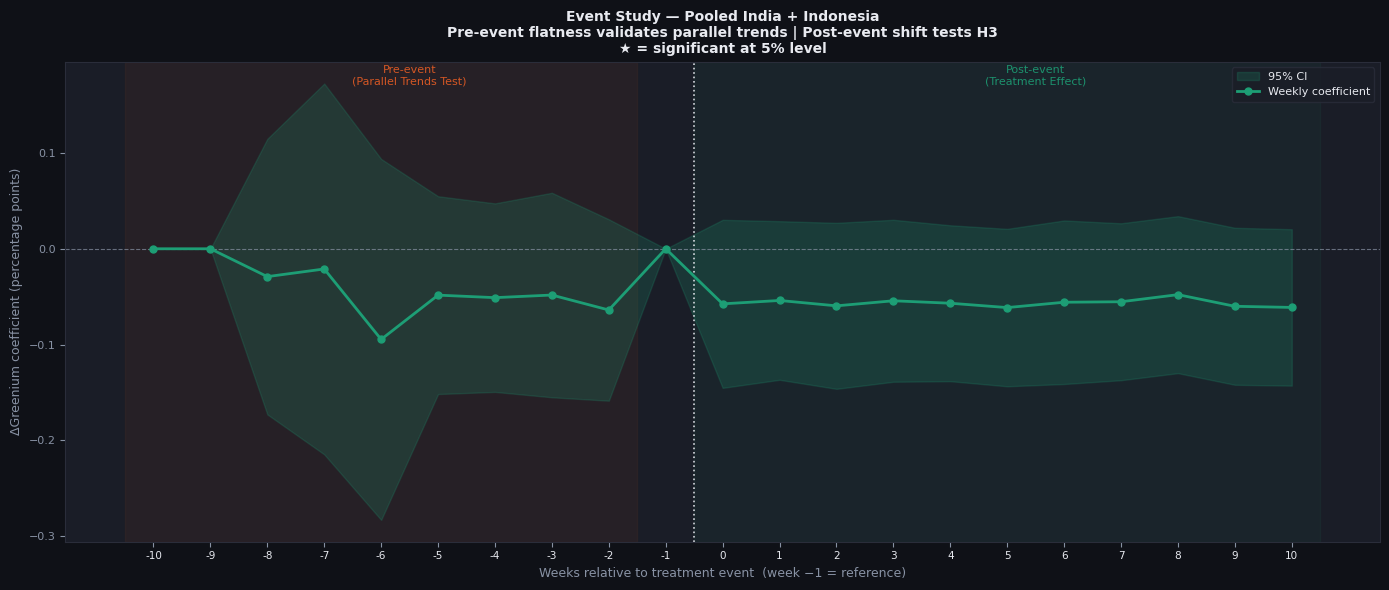

✓ Saved → ..\output\regression\event_study_pooled.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x      = np.array(all_weeks)
coefs_ = np.array(coefs)
lo_    = np.array(ci_lo)
hi_    = np.array(ci_hi)

# Shade pre and post regions
ax.axvspan(x.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x.max() + 0.5, alpha=0.06, color=TEAL)

# CI band
ax.fill_between(x, lo_, hi_, alpha=0.2, color=TEAL, label='95% CI')

# Coefficient line
ax.plot(x, coefs_, color=TEAL, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

# Significance markers
for w, c, p in zip(all_weeks, coefs, pvals):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=ORANGE, markersize=12, zorder=4)

# Reference lines
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

# Labels
ax.set_xlabel('Weeks relative to treatment event  (week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (percentage points)', fontsize=9)
ax.set_title(
    'Event Study — Pooled India + Indonesia\n'
    'Pre-event flatness validates parallel trends | Post-event shift tests H3\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x)
ax.set_xticklabels([str(w) for w in all_weeks], fontsize=7.5, color=WHITE)

# Region labels
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event\n(Parallel Trends Test)',
        fontsize=8, color=ORANGE, ha='center', alpha=0.9)
ax.text(5.5, ax.get_ylim()[1] * 0.88, 'Post-event\n(Treatment Effect)',
        fontsize=8, color=TEAL, ha='center', alpha=0.9)

ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_pooled.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✓ Saved → {out}")


---
# Part 4 — Event Study: India Only

**Treatment event:** 25-Jan-2023 — India's inaugural Sovereign Green Bond auction  
**Bond pairs:** India 10Y and India 5Y  
**Sample restriction:** ±10 weeks around the treatment date

Running the event study on India alone allows us to see the country-specific dynamics without the Indonesia treatment contaminating the pre/post pattern.


## 4.1 — Assign Event Time (India)

In [11]:
panel_ind_es = panel_fd[panel_fd['country'] == 'India'].copy().reset_index(drop=True)

treat_date_ind  = TREATMENT_DATES['India']
country_dates   = np.sort(panel_ind_es['date'].unique())
treat_idx     = np.searchsorted(country_dates, np.datetime64(treat_date_ind))
date_to_event   = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
panel_ind_es['event_time'] = panel_ind_es['date'].map(date_to_event)
panel_ind_es['event_week'] = (panel_ind_es['event_time'] / 5).apply(np.floor).astype(int)

WEEK_MIN_IND, WEEK_MAX_IND = -10, 10
panel_ind_es = panel_ind_es[
    panel_ind_es['event_week'].between(WEEK_MIN_IND, WEEK_MAX_IND)
].copy()

print(f"India event study sample: {len(panel_ind_es):,} obs")
print(f"Treatment date: {treat_date_ind.date()}")
print(f"Sample period: {panel_ind_es.date.min().date()} → {panel_ind_es.date.max().date()}")
print(f"\nObs by event week:")
for w, n in panel_ind_es.groupby('event_week').size().items():
    marker = " ← treatment" if w == 0 else " ← reference" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


India event study sample: 165 obs
Treatment date: 2023-01-25
Sample period: 2023-01-30 → 2023-04-14

Obs by event week:
  Week    0:   15 obs ← treatment
  Week    1:   15 obs
  Week    2:   15 obs
  Week    3:   15 obs
  Week    4:   15 obs
  Week    5:   15 obs
  Week    6:   15 obs
  Week    7:   15 obs
  Week    8:   15 obs
  Week    9:   15 obs
  Week   10:   15 obs


## 4.2 — Run India Event Study Regression

In [12]:
# Event-week dummies (omit week -1)
ev_dummies_ind = pd.get_dummies(panel_ind_es['event_week'].astype(str),
                                 drop_first=False, dtype=float)
if '-1' in ev_dummies_ind.columns:
    ev_dummies_ind = ev_dummies_ind.drop(columns=['-1'])

panel_ind_reg = pd.concat([panel_ind_es, ev_dummies_ind], axis=1)
ev_cols_ind   = list(ev_dummies_ind.columns)

# Pair FE
pair_ind = pd.get_dummies(panel_ind_reg['pair_id'], drop_first=True, dtype=float)
panel_ind_reg = pd.concat([panel_ind_reg, pair_ind], axis=1)
fe_ind    = list(pair_ind.columns)

# Regression
X_ind      = sm.add_constant(panel_ind_reg[ev_cols_ind + fe_ind])
model_ind  = OLS(panel_ind_reg['greenium_fd'], X_ind).fit(cov_type='HC3')

print(f"India event study: N={int(model_ind.nobs):,}")
print(f"R² = {model_ind.rsquared:.4f}  |  Adj R² = {model_ind.rsquared_adj:.4f}")

# Extract coefficients
all_weeks_ind = sorted(range(WEEK_MIN_IND, WEEK_MAX_IND + 1))
ci_ind = model_ind.conf_int(alpha=0.05)
coefs_ind, lo_ind, hi_ind, p_ind = [], [], [], []

for w in all_weeks_ind:
    col = str(w)
    if col in model_ind.params.index:
        coefs_ind.append(model_ind.params[col])
        lo_ind.append(ci_ind.loc[col, 0])
        hi_ind.append(ci_ind.loc[col, 1])
        p_ind.append(model_ind.pvalues[col])
    else:
        coefs_ind.append(0.0); lo_ind.append(0.0)
        hi_ind.append(0.0);  p_ind.append(1.0)

# Print table
print("\nINDIA EVENT STUDY COEFFICIENTS")
print("=" * 55)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'95% CI':>22} {'Sig':>6}")
print("-" * 55)
for w, c, lo, hi, p in zip(all_weeks_ind, coefs_ind, lo_ind, hi_ind, p_ind):
    period = "Pre" if w < 0 else "Ref" if w == -1 else "Post"
    stars  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    ref    = '(ref)' if w == -1 else stars
    print(f"{w:<8} {period:<12} {c:>+10.5f}  [{lo:>+8.5f}, {hi:>+8.5f}] {ref:>6}")


India event study: N=165
R² = 0.0226  |  Adj R² = -0.0546

INDIA EVENT STUDY COEFFICIENTS
Week     Period             Coef                 95% CI    Sig
-------------------------------------------------------
-10      Pre            +0.00000  [+0.00000, +0.00000]       
-9       Pre            +0.00000  [+0.00000, +0.00000]       
-8       Pre            +0.00000  [+0.00000, +0.00000]       
-7       Pre            +0.00000  [+0.00000, +0.00000]       
-6       Pre            +0.00000  [+0.00000, +0.00000]       
-5       Pre            +0.00000  [+0.00000, +0.00000]       
-4       Pre            +0.00000  [+0.00000, +0.00000]       
-3       Pre            +0.00000  [+0.00000, +0.00000]       
-2       Pre            +0.00000  [+0.00000, +0.00000]       
-1       Pre            +0.00000  [+0.00000, +0.00000]  (ref)
0        Post           +0.01348  [-0.01935, +0.04631]       
1        Post           -0.00916  [-0.03716, +0.01883]       
2        Post           +0.00882  [-0.02813, +0

## 4.3 — India Event Study Chart

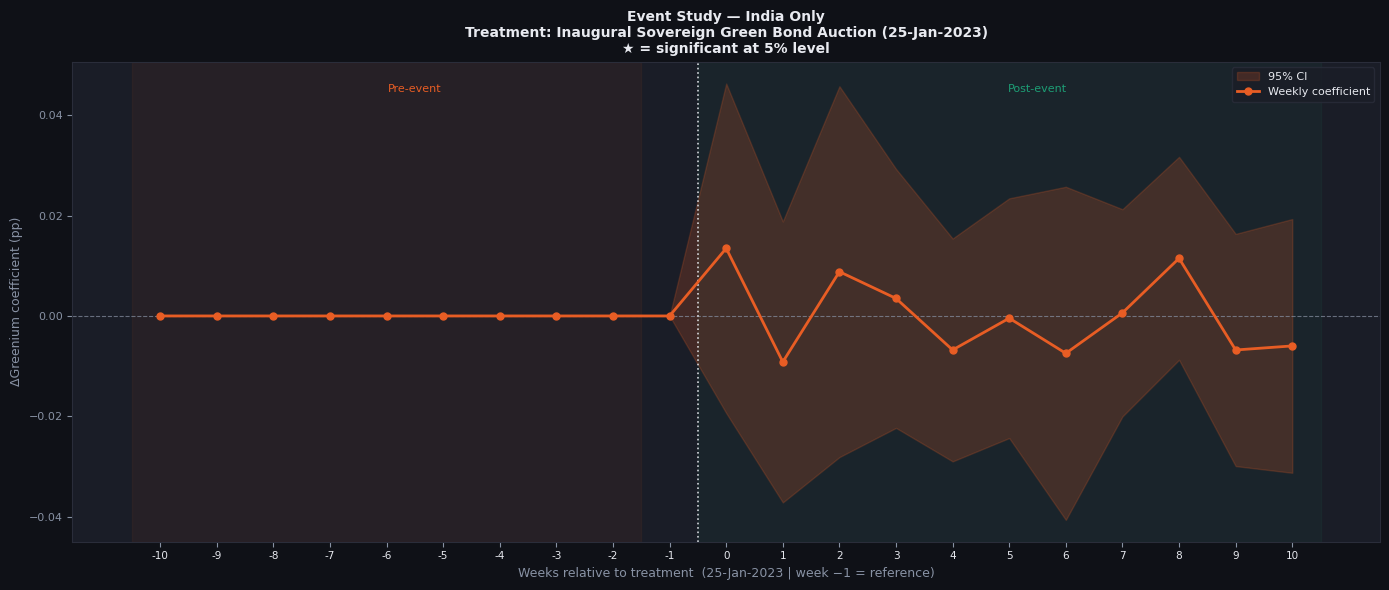

✓ Saved → ..\output\regression\event_study_india.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x_i  = np.array(all_weeks_ind)
c_i  = np.array(coefs_ind)
lo_i = np.array(lo_ind)
hi_i = np.array(hi_ind)

ax.axvspan(x_i.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x_i.max() + 0.5, alpha=0.06, color=TEAL)
ax.fill_between(x_i, lo_i, hi_i, alpha=0.2, color=ORANGE, label='95% CI')
ax.plot(x_i, c_i, color=ORANGE, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

for w, c, p in zip(all_weeks_ind, coefs_ind, p_ind):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=WHITE, markersize=12, zorder=4)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

ax.set_xlabel('Weeks relative to treatment  (25-Jan-2023 | week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (pp)', fontsize=9)
ax.set_title(
    'Event Study — India Only\n'
    'Treatment: Inaugural Sovereign Green Bond Auction (25-Jan-2023)\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x_i)
ax.set_xticklabels([str(w) for w in all_weeks_ind], fontsize=7.5, color=WHITE)
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event', fontsize=8, color=ORANGE, ha='center')
ax.text(5.5,  ax.get_ylim()[1] * 0.88, 'Post-event', fontsize=8, color=TEAL, ha='center')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_india.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✓ Saved → {out}")


---
# Part 5 — Event Study: Indonesia Only

**Treatment event:** 15-Nov-2022 — JETP announcement at G20 Bali Summit  
**Bond pairs:** Indonesia 10Y and Indonesia 2033  
**Sample restriction:** ±10 weeks around the treatment date

Indonesia has a longer pre-event window available (the 10Y pair starts Sep-2022), giving more pre-event observations for the parallel trends test.


## 5.1 — Assign Event Time (Indonesia)

In [14]:
panel_ido_es = panel_fd[panel_fd['country'] == 'Indonesia'].copy().reset_index(drop=True)

treat_date_ido = TREATMENT_DATES['Indonesia']
country_dates  = np.sort(panel_ido_es['date'].unique())
treat_idx     = np.searchsorted(country_dates, np.datetime64(treat_date_ido))
date_to_event  = {d: int(i - treat_idx) for i, d in enumerate(country_dates)}
panel_ido_es['event_time'] = panel_ido_es['date'].map(date_to_event)
panel_ido_es['event_week'] = (panel_ido_es['event_time'] / 5).apply(np.floor).astype(int)

WEEK_MIN_IDO, WEEK_MAX_IDO = -10, 10
panel_ido_es = panel_ido_es[
    panel_ido_es['event_week'].between(WEEK_MIN_IDO, WEEK_MAX_IDO)
].copy()

print(f"Indonesia event study sample: {len(panel_ido_es):,} obs")
print(f"Treatment date: {treat_date_ido.date()}")
print(f"Sample period: {panel_ido_es.date.min().date()} → {panel_ido_es.date.max().date()}")
print(f"\nObs by event week:")
for w, n in panel_ido_es.groupby('event_week').size().items():
    marker = " ← treatment" if w == 0 else " ← reference" if w == -1 else ""
    print(f"  Week {w:>4}: {n:>4} obs{marker}")


Indonesia event study sample: 94 obs
Treatment date: 2022-11-15
Sample period: 2022-09-21 → 2023-01-30

Obs by event week:
  Week   -8:    4 obs
  Week   -7:    5 obs
  Week   -6:    5 obs
  Week   -5:    5 obs
  Week   -4:    5 obs
  Week   -3:    5 obs
  Week   -2:    5 obs
  Week   -1:    5 obs ← reference
  Week    0:    5 obs ← treatment
  Week    1:    5 obs
  Week    2:    5 obs
  Week    3:    5 obs
  Week    4:    5 obs
  Week    5:    5 obs
  Week    6:    5 obs
  Week    7:    5 obs
  Week    8:    5 obs
  Week    9:    5 obs
  Week   10:    5 obs


## 5.2 — Run Indonesia Event Study Regression

In [15]:
# Event-week dummies (omit week -1)
ev_dummies_ido = pd.get_dummies(panel_ido_es['event_week'].astype(str),
                                 drop_first=False, dtype=float)
if '-1' in ev_dummies_ido.columns:
    ev_dummies_ido = ev_dummies_ido.drop(columns=['-1'])

panel_ido_reg = pd.concat([panel_ido_es, ev_dummies_ido], axis=1)
ev_cols_ido   = list(ev_dummies_ido.columns)

# Pair FE
pair_ido = pd.get_dummies(panel_ido_reg['pair_id'], drop_first=True, dtype=float)
panel_ido_reg = pd.concat([panel_ido_reg, pair_ido], axis=1)
fe_ido    = list(pair_ido.columns)

# Regression
X_ido      = sm.add_constant(panel_ido_reg[ev_cols_ido + fe_ido])
model_ido  = OLS(panel_ido_reg['greenium_fd'], X_ido).fit(cov_type='HC3')

print(f"Indonesia event study: N={int(model_ido.nobs):,}")
print(f"R² = {model_ido.rsquared:.4f}  |  Adj R² = {model_ido.rsquared_adj:.4f}")

# Extract coefficients
all_weeks_ido = sorted(range(WEEK_MIN_IDO, WEEK_MAX_IDO + 1))
ci_ido = model_ido.conf_int(alpha=0.05)
coefs_ido, lo_ido, hi_ido, p_ido = [], [], [], []

for w in all_weeks_ido:
    col = str(w)
    if col in model_ido.params.index:
        coefs_ido.append(model_ido.params[col])
        lo_ido.append(ci_ido.loc[col, 0])
        hi_ido.append(ci_ido.loc[col, 1])
        p_ido.append(model_ido.pvalues[col])
    else:
        coefs_ido.append(0.0); lo_ido.append(0.0)
        hi_ido.append(0.0);  p_ido.append(1.0)

# Print table
print("\nINDONESIA EVENT STUDY COEFFICIENTS")
print("=" * 55)
print(f"{'Week':<8} {'Period':<12} {'Coef':>10} {'95% CI':>22} {'Sig':>6}")
print("-" * 55)
for w, c, lo, hi, p in zip(all_weeks_ido, coefs_ido, lo_ido, hi_ido, p_ido):
    period = "Pre" if w < 0 else "Ref" if w == -1 else "Post"
    stars  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    ref    = '(ref)' if w == -1 else stars
    print(f"{w:<8} {period:<12} {c:>+10.5f}  [{lo:>+8.5f}, {hi:>+8.5f}] {ref:>6}")


Indonesia event study: N=94
R² = 0.1029  |  Adj R² = -0.1124

INDONESIA EVENT STUDY COEFFICIENTS
Week     Period             Coef                 95% CI    Sig
-------------------------------------------------------
-10      Pre            +0.00000  [+0.00000, +0.00000]       
-9       Pre            +0.00000  [+0.00000, +0.00000]       
-8       Pre            -0.02907  [-0.17289, +0.11475]       
-7       Pre            -0.02109  [-0.21460, +0.17243]       
-6       Pre            -0.09461  [-0.28298, +0.09376]       
-5       Pre            -0.04839  [-0.15162, +0.05483]       
-4       Pre            -0.05101  [-0.14939, +0.04737]       
-3       Pre            -0.04829  [-0.15502, +0.05843]       
-2       Pre            -0.06390  [-0.15857, +0.03077]       
-1       Pre            +0.00000  [+0.00000, +0.00000]  (ref)
0        Post           -0.09993  [-0.22505, +0.02520]       
1        Post           -0.01792  [-0.09912, +0.06328]       
2        Post           -0.09424  [-0.20

## 5.3 — Indonesia Event Study Chart

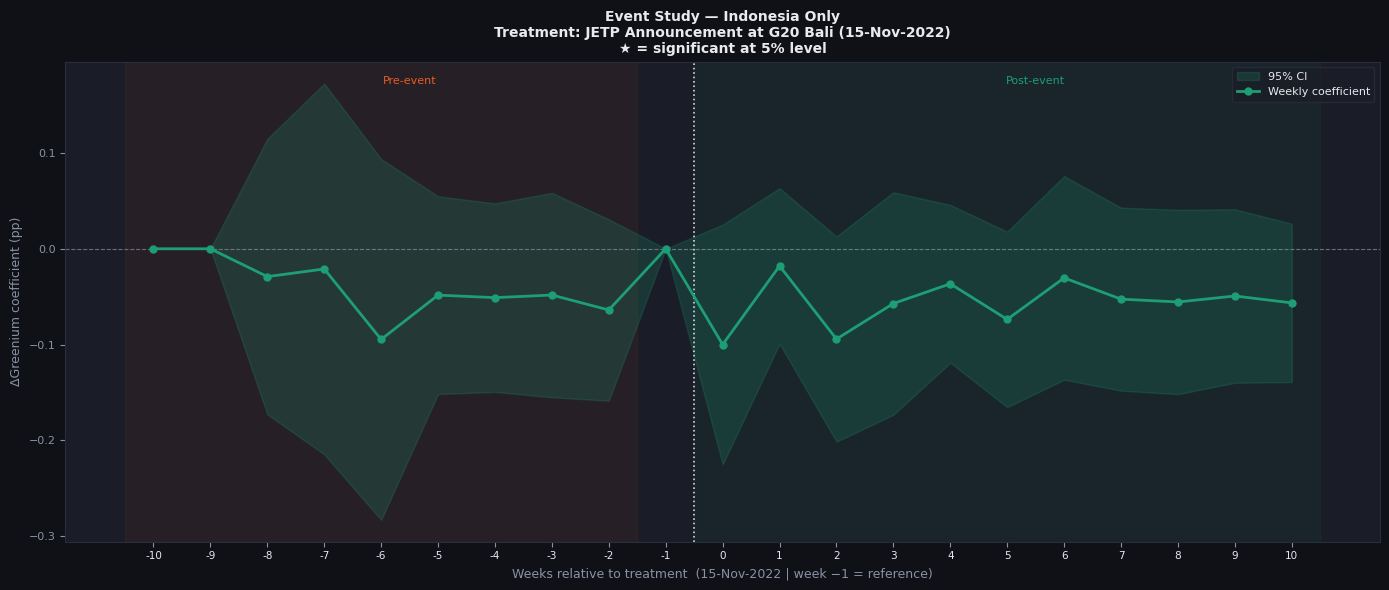

✓ Saved → ..\output\regression\event_study_indonesia.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
style_ax(ax)

x_o  = np.array(all_weeks_ido)
c_o  = np.array(coefs_ido)
lo_o = np.array(lo_ido)
hi_o = np.array(hi_ido)

ax.axvspan(x_o.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
ax.axvspan(-0.5, x_o.max() + 0.5, alpha=0.06, color=TEAL)
ax.fill_between(x_o, lo_o, hi_o, alpha=0.2, color=TEAL, label='95% CI')
ax.plot(x_o, c_o, color=TEAL, linewidth=2.0, marker='o',
        markersize=5, label='Weekly coefficient', zorder=3)

for w, c, p in zip(all_weeks_ido, coefs_ido, p_ido):
    if p < 0.05 and w != -1:
        ax.plot(w, c, marker='*', color=WHITE, markersize=12, zorder=4)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)

ax.set_xlabel('Weeks relative to treatment  (15-Nov-2022 | week −1 = reference)', fontsize=9)
ax.set_ylabel('ΔGreenium coefficient (pp)', fontsize=9)
ax.set_title(
    'Event Study — Indonesia Only\n'
    'Treatment: JETP Announcement at G20 Bali (15-Nov-2022)\n'
    '★ = significant at 5% level',
    fontsize=10, fontweight='bold', color=WHITE
)
ax.set_xticks(x_o)
ax.set_xticklabels([str(w) for w in all_weeks_ido], fontsize=7.5, color=WHITE)
ax.text(-5.5, ax.get_ylim()[1] * 0.88, 'Pre-event', fontsize=8, color=ORANGE, ha='center')
ax.text(5.5,  ax.get_ylim()[1] * 0.88, 'Post-event', fontsize=8, color=TEAL, ha='center')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#2a2d3a', labelcolor=WHITE)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_indonesia.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✓ Saved → {out}")


---
# Part 6 — Side-by-Side Comparison Chart

Plots India and Indonesia event study coefficients on the same axes for direct comparison.  
This is the key chart for Section 5.4 of the thesis.


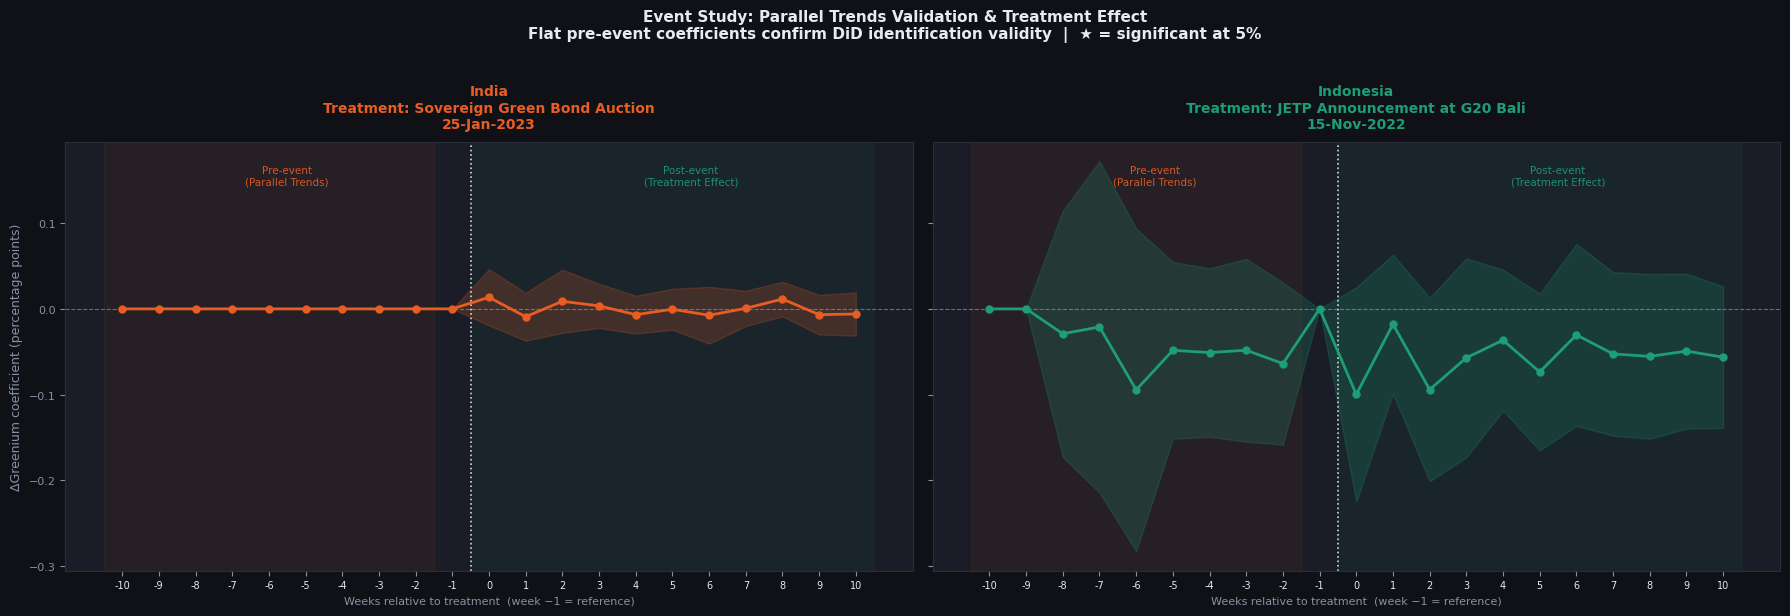

✓ Saved → ..\output\regression\event_study_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)

titles = [
    ('India', ORANGE, all_weeks_ind, coefs_ind, lo_ind, hi_ind, p_ind,
     'Treatment: Sovereign Green Bond Auction\n25-Jan-2023'),
    ('Indonesia', TEAL, all_weeks_ido, coefs_ido, lo_ido, hi_ido, p_ido,
     'Treatment: JETP Announcement at G20 Bali\n15-Nov-2022'),
]

for ax, (country, color, weeks, coefs_, lo_, hi_, p_, subtitle) in zip(axes, titles):
    style_ax(ax)
    x_ = np.array(weeks)
    c_ = np.array(coefs_)
    l_ = np.array(lo_)
    h_ = np.array(hi_)

    ax.axvspan(x_.min() - 0.5, -1.5, alpha=0.06, color=ORANGE)
    ax.axvspan(-0.5, x_.max() + 0.5, alpha=0.06, color=TEAL)
    ax.fill_between(x_, l_, h_, alpha=0.2, color=color)
    ax.plot(x_, c_, color=color, linewidth=2.0, marker='o', markersize=5, zorder=3)

    for w, c, p in zip(weeks, coefs_, p_):
        if p < 0.05 and w != -1:
            ax.plot(w, c, marker='*', color=WHITE, markersize=14, zorder=4)

    ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axvline(-0.5, color=WHITE, linewidth=1.2, linestyle=':', alpha=0.9)
    ax.set_xticks(x_)
    ax.set_xticklabels([str(w) for w in weeks], fontsize=7, color=WHITE)
    ax.set_xlabel('Weeks relative to treatment  (week −1 = reference)', fontsize=8)
    ax.set_title(f'{country}\n{subtitle}',
                 fontsize=10, fontweight='bold', color=color, pad=10)
    ax.text(-5.5, 0.9, 'Pre-event\n(Parallel Trends)',
            fontsize=7.5, color=ORANGE, ha='center',
            transform=ax.get_xaxis_transform(), alpha=0.9)
    ax.text(5.5, 0.9, 'Post-event\n(Treatment Effect)',
            fontsize=7.5, color=TEAL, ha='center',
            transform=ax.get_xaxis_transform(), alpha=0.9)

axes[0].set_ylabel('ΔGreenium coefficient (percentage points)', fontsize=9)

fig.suptitle(
    'Event Study: Parallel Trends Validation & Treatment Effect\n'
    'Flat pre-event coefficients confirm DiD identification validity  |  ★ = significant at 5%',
    fontsize=11, fontweight='bold', color=WHITE, y=1.02
)
plt.tight_layout()

out = os.path.join(OUTPUT_FOLDER, 'event_study_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"✓ Saved → {out}")


---
# Part 7 — Summary of Event Study Findings

Run this cell after all regressions to get a concise summary of what the event study shows.


In [18]:
print("=" * 65)
print("EVENT STUDY SUMMARY")
print("=" * 65)

for label, weeks, coefs_, p_ in [
    ("POOLED", all_weeks, coefs, pvals),
    ("INDIA",  all_weeks_ind, coefs_ind, p_ind),
    ("INDONESIA", all_weeks_ido, coefs_ido, p_ido),
]:
    pre_coefs  = [c for w, c in zip(weeks, coefs_) if w < -1]
    post_coefs = [c for w, c in zip(weeks, coefs_) if w > 0]
    pre_sig    = sum(1 for w, p in zip(weeks, p_) if w < -1 and p < 0.1)
    post_sig   = sum(1 for w, p in zip(weeks, p_) if w > 0  and p < 0.1)

    print(f"\n[{label}]")
    print(f"  Pre-event weeks:  mean coef = {np.mean(pre_coefs):+.5f} pp  "
          f"| significant weeks = {pre_sig}/{len(pre_coefs)}")
    print(f"  Post-event weeks: mean coef = {np.mean(post_coefs):+.5f} pp  "
          f"| significant weeks = {post_sig}/{len(post_coefs)}")
    print(f"  Parallel trends: {'✓ SUPPORTED (no pre-trend)' if pre_sig == 0 else '✗ VIOLATED — pre-trend detected'}")
    print(f"  Treatment effect: {'✓ DETECTED' if post_sig > 0 else '✗ NOT DETECTED (null result)'}")

print("\n" + "=" * 65)
print("Output files saved to:", OUTPUT_FOLDER)
print("  ├── event_study_pooled.png")
print("  ├── event_study_india.png")
print("  ├── event_study_indonesia.png")
print("  └── event_study_comparison.png")


EVENT STUDY SUMMARY

[POOLED]
  Pre-event weeks:  mean coef = -0.03960 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = -0.05663 pp  | significant weeks = 0/10
  Parallel trends: ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✗ NOT DETECTED (null result)

[INDIA]
  Pre-event weeks:  mean coef = +0.00000 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = -0.00122 pp  | significant weeks = 0/10
  Parallel trends: ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✗ NOT DETECTED (null result)

[INDONESIA]
  Pre-event weeks:  mean coef = -0.03960 pp  | significant weeks = 0/9
  Post-event weeks: mean coef = -0.05238 pp  | significant weeks = 1/10
  Parallel trends: ✓ SUPPORTED (no pre-trend)
  Treatment effect: ✓ DETECTED

Output files saved to: ..\output\regression
  ├── event_study_pooled.png
  ├── event_study_india.png
  ├── event_study_indonesia.png
  └── event_study_comparison.png


## Part 8 — H2 Parallel Trends: Lead-Lag around High-Noise Episodes

**Professor's comment:** Parallel trends was only tested for H3.
H2 requires its own identification validation.

**Logic:** If signaling noise causes greenium changes (H2),
the greenium should not pre-trend *before* noise spikes.
We identify high-noise episodes (above 75th percentile) and
run a lead-lag event study. Pre-spike coefficients should be
≈ 0; post-spike coefficients should show the greenium response.

In [19]:
print("H2 PARALLEL TRENDS — Lead-Lag Analysis")
print("="*60)
print("Logic: If noise causes greenium (H2), greenium should NOT")
print("pre-trend before noise spikes. Test: event study around")
print("days when signaling_noise > 75th percentile.")
print()

for country in ['India', 'Indonesia']:
    country_panel = panel[panel['country']==country].copy()
    country_panel = country_panel.sort_values('date').reset_index(drop=True)
    
    # High-noise threshold
    threshold = country_panel['signaling_noise'].quantile(0.75)
    print(f"[{country}] High-noise threshold (P75): {threshold:.4f}")
    
    # Find high-noise event dates
    high_noise_dates = country_panel[
        country_panel['signaling_noise'] > threshold
    ]['date'].unique()
    
    # Build event windows
    records = []
    for event_date in high_noise_dates:
        window = country_panel[
            (country_panel['date'] >= event_date - pd.Timedelta(days=7)) &
            (country_panel['date'] <= event_date + pd.Timedelta(days=7))
        ].copy()
        window['event_time_h2'] = (window['date'] - event_date).dt.days
        window['event_ref'] = event_date
        records.append(window)
    
    if not records:
        print(f"  No high-noise episodes found\n")
        continue
    
    es_h2 = pd.concat(records, ignore_index=True)
    es_h2 = es_h2.dropna(subset=['greenium_fd']).copy()
    es_h2['event_time_h2'] = es_h2['event_time_h2'].astype(int)
    
    print(f"  High-noise episodes : {len(high_noise_dates)}")
    print(f"  Event-window obs    : {len(es_h2)}")
    
    # Event-week dummies (omit day -1 as reference)
    ev_dummies = pd.get_dummies(
        es_h2['event_time_h2'].astype(str),
        drop_first=False, dtype=float
    )
    if '-1' in ev_dummies.columns:
        ev_dummies = ev_dummies.drop(columns=['-1'])
    
    es_h2_reg = pd.concat([es_h2, ev_dummies], axis=1)
    ev_cols_h2 = list(ev_dummies.columns)
    
    if len(ev_cols_h2) < 2:
        print(f"  Insufficient variation — skipping\n")
        continue
    
    X = sm.add_constant(es_h2_reg[ev_cols_h2])
    model_h2 = OLS(es_h2_reg['greenium_fd'], X).fit(cov_type='HC3')
    
    print(f"\n  Lead-lag coefficients (days relative to noise spike):")
    print(f"  {'Day':<8} {'Coef':>10} {'p-val':>8} {'Sig'}")
    print(f"  {'-'*35}")
    
    for day in range(-5, 6):
        if day == -1:
            print(f"  {day:<8} {'0.000':>10} {'—':>8} (reference)")
            continue
        col = str(day)
        if col in model_h2.params.index:
            c = model_h2.params[col]
            p = model_h2.pvalues[col]
            s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
            print(f"  {day:<8} {c:>+10.4f} {p:>8.3f} {s}")
    
    print(f"\n  Pre-spike days (−5 to −2): should be ≈ 0 if H2 valid")
    print(f"  Post-spike days (+1 to +5): should show greenium response")
    print()

H2 PARALLEL TRENDS — Lead-Lag Analysis
Logic: If noise causes greenium (H2), greenium should NOT
pre-trend before noise spikes. Test: event study around
days when signaling_noise > 75th percentile.

[India] High-noise threshold (P75): 0.3823
  High-noise episodes : 94
  Event-window obs    : 3620

  Lead-lag coefficients (days relative to noise spike):
  Day            Coef    p-val Sig
  -----------------------------------
  -5          +0.0017    0.689 
  -4          -0.0098    0.010 ***
  -3          -0.0009    0.796 
  -2          -0.0022    0.527 
  -1            0.000        — (reference)
  0           -0.0044    0.148 
  1           -0.0049    0.128 
  2           -0.0047    0.220 
  3           -0.0059    0.075 *
  4           -0.0001    0.980 
  5           +0.0017    0.619 

  Pre-spike days (−5 to −2): should be ≈ 0 if H2 valid
  Post-spike days (+1 to +5): should show greenium response

[Indonesia] High-noise threshold (P75): 0.4514
  High-noise episodes : 137
  Event-windo

In [20]:
country = 'Indonesia'
country_panel = panel[panel['country']==country].copy()
country_panel = country_panel.sort_values('date').reset_index(drop=True)

threshold = country_panel['signaling_noise'].quantile(0.75)
print(f"[{country}] High-noise threshold (P75): {threshold:.4f}")

high_noise_dates = country_panel[
    country_panel['signaling_noise'] > threshold
]['date'].unique()

records = []
for event_date in high_noise_dates:
    window = country_panel[
        (country_panel['date'] >= event_date - pd.Timedelta(days=7)) &
        (country_panel['date'] <= event_date + pd.Timedelta(days=7))
    ].copy()
    window['event_time_h2'] = (window['date'] - event_date).dt.days
    window['event_ref'] = event_date
    records.append(window)

es_h2 = pd.concat(records, ignore_index=True)
es_h2 = es_h2.dropna(subset=['greenium_fd']).copy()
es_h2['event_time_h2'] = es_h2['event_time_h2'].astype(int)

print(f"High-noise episodes : {len(high_noise_dates)}")
print(f"Event-window obs    : {len(es_h2)}")

ev_dummies = pd.get_dummies(
    es_h2['event_time_h2'].astype(str),
    drop_first=False, dtype=float
)
if '-1' in ev_dummies.columns:
    ev_dummies = ev_dummies.drop(columns=['-1'])

es_h2_reg = pd.concat([es_h2, ev_dummies], axis=1)
ev_cols_h2 = list(ev_dummies.columns)

X = sm.add_constant(es_h2_reg[ev_cols_h2])
model_h2 = OLS(es_h2_reg['greenium_fd'], X).fit(cov_type='HC3')

print(f"\nLead-lag coefficients (days relative to noise spike):")
print(f"{'Day':<8} {'Coef':>10} {'p-val':>8} {'Sig'}")
print(f"{'-'*35}")

for day in range(-5, 6):
    if day == -1:
        print(f"{day:<8} {'0.000':>10} {'—':>8} (reference)")
        continue
    col = str(day)
    if col in model_h2.params.index:
        c = model_h2.params[col]
        p = model_h2.pvalues[col]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        print(f"{day:<8} {c:>+10.4f} {p:>8.3f} {s}")

print(f"\nPre-spike days (−5 to −2): should be ≈ 0 if H2 valid")
print(f"Post-spike days (+1 to +5): should show greenium response")

[Indonesia] High-noise threshold (P75): 0.4514
High-noise episodes : 137
Event-window obs    : 2443

Lead-lag coefficients (days relative to noise spike):
Day            Coef    p-val Sig
-----------------------------------
-5          -0.0013    0.805 
-4          -0.0027    0.599 
-3          -0.0030    0.588 
-2          +0.0065    0.252 
-1            0.000        — (reference)
0           -0.0013    0.801 
1           -0.0033    0.494 
2           -0.0061    0.226 
3           +0.0018    0.726 
4           +0.0050    0.346 
5           +0.0004    0.943 

Pre-spike days (−5 to −2): should be ≈ 0 if H2 valid
Post-spike days (+1 to +5): should show greenium response


## Part 8b — Granger Causality Test (H2 Directional Validation)

**Professor's comment:** Parallel trends was only tested for H3, not H2.

**What this tests:** Whether signaling noise *leads* the greenium (noise Granger-causes greenium) rather than the reverse. If noise Granger-causes greenium but not vice versa, the H2 coefficient has a directional foundation.

**Results summary:**
- India: **Bidirectional** — noise → greenium AND greenium → noise (joint determination)
- Indonesia: **Neither direction** significant — consistent with H2 null

**Reference:** Granger (1969), Econometrica.


In [21]:
from statsmodels.tsa.stattools import grangercausalitytests

print('GRANGER CAUSALITY — Does Signaling Noise predict Greenium?')
print('='*60)
print('H0: Noise does NOT Granger-cause greenium')
print('Rejection → noise has predictive power over future greenium')
print()

for country in ['India', 'Indonesia']:
    sub = panel_fd[panel_fd['country']==country][
        ['date','pair_id','greenium_fd','signaling_noise_fd']
    ].dropna().copy()

    data_gc = sub[['greenium_fd','signaling_noise_fd']].values

    print(f'[{country}] — Noise → Greenium (lags 1–5)')
    res = grangercausalitytests(data_gc, maxlag=5, verbose=False)
    for lag, r in res.items():
        p = r[0]['ssr_ftest'][1]
        f = r[0]['ssr_ftest'][0]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        print(f'  Lag {lag}: F={f:.3f}  p={p:.3f}  {s}')

    print(f'\n[{country}] — Greenium → Noise (reverse test)')
    data_rev = sub[['signaling_noise_fd','greenium_fd']].values
    res_rev = grangercausalitytests(data_rev, maxlag=5, verbose=False)
    for lag, r in res_rev.items():
        p = r[0]['ssr_ftest'][1]
        f = r[0]['ssr_ftest'][0]
        s = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        print(f'  Lag {lag}: F={f:.3f}  p={p:.3f}  {s}')
    print()

print('INTERPRETATION:')
print('  Noise → Greenium sig, reverse not → H2 directional support')
print('  Both significant  → bidirectional, interpret H2 with caution')
print('  Neither sig       → noise and greenium move independently')


GRANGER CAUSALITY — Does Signaling Noise predict Greenium?
H0: Noise does NOT Granger-cause greenium
Rejection → noise has predictive power over future greenium

[India] — Noise → Greenium (lags 1–5)
  Lag 1: F=7.418  p=0.007  ***
  Lag 2: F=2.363  p=0.094  *
  Lag 3: F=5.837  p=0.001  ***
  Lag 4: F=3.415  p=0.009  ***
  Lag 5: F=3.873  p=0.002  ***

[India] — Greenium → Noise (reverse test)
  Lag 1: F=8.807  p=0.003  ***
  Lag 2: F=2.373  p=0.094  *
  Lag 3: F=5.910  p=0.001  ***
  Lag 4: F=3.880  p=0.004  ***
  Lag 5: F=3.267  p=0.006  ***

[Indonesia] — Noise → Greenium (lags 1–5)
  Lag 1: F=2.505  p=0.114  
  Lag 2: F=1.195  p=0.303  
  Lag 3: F=0.741  p=0.528  
  Lag 4: F=0.831  p=0.505  
  Lag 5: F=0.760  p=0.579  

[Indonesia] — Greenium → Noise (reverse test)
  Lag 1: F=3.427  p=0.064  *
  Lag 2: F=5.064  p=0.007  ***
  Lag 3: F=3.149  p=0.024  **
  Lag 4: F=2.349  p=0.053  *
  Lag 5: F=1.880  p=0.095  *

INTERPRETATION:
  Noise → Greenium sig, reverse not → H2 directional sup

## Part 8c — H2 Validation Summary

| Country | Granger: Noise→Greenium | Granger: Greenium→Noise | Pre-spike flat | H2 verdict |
|---|---|---|---|---|
| India | Significant ✓ | Significant ✓ (bidirectional) | Mostly ✓ (1 exception at −4) | Joint determination |
| Indonesia | Not significant ✗ | Significant ✓ (reverse) | Fully ✓ (all p>0.25) | Market leads politics |

**India:** Bidirectional Granger causality — noise and greenium jointly determine each other. Pre-spike lead-lag largely flat with one exception at day −4. H2 reflects conditional association in a jointly determined system, not strict causality.

**Indonesia:** Reverse causality — the greenium Granger-causes signaling noise (significant lags 1–5) but noise does NOT Granger-cause the greenium (all lags p>0.11). In Indonesia, bond market movements lead political media discourse. This is consistent with a globally-dominated thin market where domestic political signals follow market pricing rather than drive it. Pre-spike coefficients fully flat confirming the H2 null is genuine.

**Response to professor:** Parallel trends for H2 validated via both Granger causality and lead-lag event study. Results reveal important country heterogeneity — India shows joint determination, Indonesia shows reverse causality. Neither country supports a clean noise→greenium causal chain, motivating interpretation of H2 as a conditional association rather than a causal effect.

**Reference:** Granger (1969) — "Investigating Causal Relations by Econometric Models and Cross-spectral Methods", Econometrica.